#Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente



#📌 Extracción

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

df = pd.read_json('/content/TelecomX_Data.json')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [7]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [8]:


# Normalizar / expandir las columnas anidadas
df_expanded = pd.json_normalize(df.to_dict(orient='records'))
df_expanded.head()



,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
# Mostrar dimensiones y columnas iniciales
print("Dimensiones del df_expanded:", df_expanded.shape)
print("Columnas:", df_expanded.columns.tolist()[:20])  # primeras 20 columnas
df_expanded.head()

Dimensiones del df_expanded: (7267, 21)
Columnas: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [10]:

# Diccionario de traducción actualizado
columnas_traducidas = {
    'customerID': 'cliente.id',
    'Churn': 'cancelacion',
    'customer.gender': 'cliente.genero',
    'customer.SeniorCitizen': 'cliente.adulto_mayor',
    'customer.Partner': 'cliente.pareja',
    'customer.Dependents': 'cliente.dependientes',
    'customer.tenure': 'cliente.antiguedad',
    'phone.PhoneService': 'telefono.servicio_telefonico',
    'phone.MultipleLines': 'telefono.multiples_lineas',
    'internet.InternetService': 'internet.servicio_internet',
    'internet.OnlineSecurity': 'internet.seguridad_online',
    'internet.OnlineBackup': 'internet.respaldo_online',
    'internet.DeviceProtection': 'internet.proteccion_dispositivo',
    'internet.TechSupport': 'internet.soporte_tecnico',
    'internet.StreamingTV': 'internet.streaming_tv',
    'internet.StreamingMovies': 'internet.streaming_peliculas',
    'account.Contract': 'cuenta.contrato',
    'account.PaperlessBilling': 'cuenta.facturacion_sin_papel',
    'account.PaymentMethod': 'cuenta.metodo_pago',
    'account.Charges.Monthly': 'cuenta.cargos_mensuales',
    'account.Charges.Total': 'cuenta.cargos_totales'
}
# Renombrar columnas
df_expanded.rename(columns=columnas_traducidas, inplace=True)

# Verificar
print("Columnas renombradas:")
print(df_expanded.columns.tolist())

Columnas renombradas:
['cliente.id', 'cancelacion', 'cliente.genero', 'cliente.adulto_mayor', 'cliente.pareja', 'cliente.dependientes', 'cliente.antiguedad', 'telefono.servicio_telefonico', 'telefono.multiples_lineas', 'internet.servicio_internet', 'internet.seguridad_online', 'internet.respaldo_online', 'internet.proteccion_dispositivo', 'internet.soporte_tecnico', 'internet.streaming_tv', 'internet.streaming_peliculas', 'cuenta.contrato', 'cuenta.facturacion_sin_papel', 'cuenta.metodo_pago', 'cuenta.cargos_mensuales', 'cuenta.cargos_totales']


In [11]:
df_expanded.head()

,cliente.id,cancelacion,cliente.genero,cliente.adulto_mayor,cliente.pareja,cliente.dependientes,cliente.antiguedad,telefono.servicio_telefonico,telefono.multiples_lineas,internet.servicio_internet,...,internet.respaldo_online,internet.proteccion_dispositivo,internet.soporte_tecnico,internet.streaming_tv,internet.streaming_peliculas,cuenta.contrato,cuenta.facturacion_sin_papel,cuenta.metodo_pago,cuenta.cargos_mensuales,cuenta.cargos_totales
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [12]:
# Resumen de columnas y tipos de datos
print("Resumen de columnas y tipos de datos:")
print(df_expanded.info())


Resumen de columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   cliente.id                       7267 non-null   object 
 1   cancelacion                      7267 non-null   object 
 2   cliente.genero                   7267 non-null   object 
 3   cliente.adulto_mayor             7267 non-null   int64  
 4   cliente.pareja                   7267 non-null   object 
 5   cliente.dependientes             7267 non-null   object 
 6   cliente.antiguedad               7267 non-null   int64  
 7   telefono.servicio_telefonico     7267 non-null   object 
 8   telefono.multiples_lineas        7267 non-null   object 
 9   internet.servicio_internet       7267 non-null   object 
 10  internet.seguridad_online        7267 non-null   object 
 11  internet.respaldo_online         7267 non-nu

In [13]:
#Estadísticas descriptivas de las variables numéricas
df_expanded.describe()


,cliente.adulto_mayor,cliente.antiguedad,cuenta.cargos_mensuales
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [14]:
# Crear la columna cuentas_diarias
df_expanded["cuenta.cuentas_diarias"] = df_expanded["cuenta.cargos_mensuales"] / 30

# Verificar primeras filas
print(df_expanded[["cuenta.cargos_mensuales", "cuenta.cuentas_diarias"]].head())


   cuenta.cargos_mensuales  cuenta.cuentas_diarias
0                     65.6                2.186667
1                     59.9                1.996667
2                     73.9                2.463333
3                     98.0                3.266667
4                     83.9                2.796667


In [15]:
# Eliminar registros donde cancelacion está vacío o nulo (no relevantes para el muestreo)
df_expanded = df_expanded[df_expanded["cancelacion"].notna()]
df_expanded = df_expanded[df_expanded["cancelacion"].str.strip() != ""]

# Reiniciar el índice
df_expanded = df_expanded.reset_index(drop=True)

# Verificar conteo después de la limpieza
print("Distribución de cancelacion después de eliminar vacíos:")
print(df_expanded["cancelacion"].value_counts())


Distribución de cancelacion después de eliminar vacíos:
cancelacion
No     5174
Yes    1869
Name: count, dtype: int64


In [16]:

for col in df_expanded.columns:
    print(f"Columna: {col}")
    print(df_expanded[col].unique())
    print("-" * 50)

Columna: cliente.id
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
--------------------------------------------------
Columna: cancelacion
['No' 'Yes']
--------------------------------------------------
Columna: cliente.genero
['Female' 'Male']
--------------------------------------------------
Columna: cliente.adulto_mayor
[0 1]
--------------------------------------------------
Columna: cliente.pareja
['Yes' 'No']
--------------------------------------------------
Columna: cliente.dependientes
['Yes' 'No']
--------------------------------------------------
Columna: cliente.antiguedad
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
--------------------------------------------------
Columna: telefono.servicio_telefonico
['Yes' 'No']
-------------------------------------------

In [17]:
#Eliminar columna cliente.id
if "cliente.id" in df_expanded.columns:
    df_expanded = df_expanded.drop(columns=["cliente.id"])

# Verificar
print("Columnas restantes:")
print(df_expanded.columns.tolist())

Columnas restantes:
['cancelacion', 'cliente.genero', 'cliente.adulto_mayor', 'cliente.pareja', 'cliente.dependientes', 'cliente.antiguedad', 'telefono.servicio_telefonico', 'telefono.multiples_lineas', 'internet.servicio_internet', 'internet.seguridad_online', 'internet.respaldo_online', 'internet.proteccion_dispositivo', 'internet.soporte_tecnico', 'internet.streaming_tv', 'internet.streaming_peliculas', 'cuenta.contrato', 'cuenta.facturacion_sin_papel', 'cuenta.metodo_pago', 'cuenta.cargos_mensuales', 'cuenta.cargos_totales', 'cuenta.cuentas_diarias']


In [18]:
# Copiamos los datos originales para diferentes modelos aplicables
df_arbol = df_expanded.copy()
df_lineal = df_expanded.copy()

In [19]:


# Definimos columnas
binarias = [
    "cancelacion",
    "cliente.genero",
    "cliente.adulto_mayor",
    "cliente.pareja",
    "cliente.dependientes",
    "telefono.servicio_telefonico",
    "cuenta.facturacion_sin_papel"
]

multiclase = [
    "telefono.multiples_lineas",
    "internet.servicio_internet",
    "internet.seguridad_online",
    "internet.respaldo_online",
    "internet.proteccion_dispositivo",
    "internet.soporte_tecnico",
    "internet.streaming_tv",
    "internet.streaming_peliculas",
    "cuenta.contrato",
    "cuenta.metodo_pago"
]

numericas = [
    "cliente.antiguedad",
    "cuenta.cargos_mensuales",
    "cuenta.cargos_totales",
    "cuenta.cuentas_diarias"
]

# Procesamiento para df_arbol con LabelEncoder en binarias y multiclase
le = LabelEncoder()
for col in binarias + multiclase:
    df_arbol[col] = le.fit_transform(df_arbol[col])

# Convertimos numéricas a float en df_arbol
for col in numericas:
    df_arbol[col] = pd.to_numeric(df_arbol[col], errors="coerce")

# Procesamiento para df_lineal con LabelEncoder en binarias
for col in binarias:
    df_lineal[col] = le.fit_transform(df_lineal[col])

# Aplicamos OneHotEncoding en multiclase para df_lineal
df_lineal = pd.get_dummies(df_lineal, columns=multiclase, drop_first=True)

# Convertimos numéricas a float en df_lineal
for col in numericas:
    df_lineal[col] = pd.to_numeric(df_lineal[col], errors="coerce")

# Verificación de forma final
print("df_arbol columnas:", df_arbol.columns.tolist()[:15], "...")
print("df_lineal columnas:", df_lineal.columns.tolist()[:15], "...")


df_arbol columnas: ['cancelacion', 'cliente.genero', 'cliente.adulto_mayor', 'cliente.pareja', 'cliente.dependientes', 'cliente.antiguedad', 'telefono.servicio_telefonico', 'telefono.multiples_lineas', 'internet.servicio_internet', 'internet.seguridad_online', 'internet.respaldo_online', 'internet.proteccion_dispositivo', 'internet.soporte_tecnico', 'internet.streaming_tv', 'internet.streaming_peliculas'] ...
df_lineal columnas: ['cancelacion', 'cliente.genero', 'cliente.adulto_mayor', 'cliente.pareja', 'cliente.dependientes', 'cliente.antiguedad', 'telefono.servicio_telefonico', 'cuenta.facturacion_sin_papel', 'cuenta.cargos_mensuales', 'cuenta.cargos_totales', 'cuenta.cuentas_diarias', 'telefono.multiples_lineas_No phone service', 'telefono.multiples_lineas_Yes', 'internet.servicio_internet_Fiber optic', 'internet.servicio_internet_No'] ...


In [20]:
# Conteo y proporción de cancelaciones en df_lineal
print("df_lineal - Conteo de cancelaciones:")
print(df_lineal["cancelacion"].value_counts())
print("\ndf_lineal - Proporción de cancelaciones:")
print(df_lineal["cancelacion"].value_counts(normalize=True))

print("\n" + "-"*50 + "\n")

# Conteo y proporción de cancelaciones en df_arbol
print("df_arbol - Conteo de cancelaciones:")
print(df_arbol["cancelacion"].value_counts())
print("\ndf_arbol - Proporción de cancelaciones:")
print(df_arbol["cancelacion"].value_counts(normalize=True))

df_lineal - Conteo de cancelaciones:
cancelacion
0    5174
1    1869
Name: count, dtype: int64

df_lineal - Proporción de cancelaciones:
cancelacion
0    0.73463
1    0.26537
Name: proportion, dtype: float64

--------------------------------------------------

df_arbol - Conteo de cancelaciones:
cancelacion
0    5174
1    1869
Name: count, dtype: int64

df_arbol - Proporción de cancelaciones:
cancelacion
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [21]:
from sklearn.impute import SimpleImputer

# Imputador para numéricos (reemplaza NaN por la media)
imputer_num = SimpleImputer(strategy="mean")

# Imputador para categóricos (reemplaza NaN por el valor más frecuente)
imputer_cat = SimpleImputer(strategy="most_frequent")

# Imputación en df_lineal
num_cols_lineal = df_lineal.select_dtypes(include=["int64", "float64"]).columns
cat_cols_lineal = df_lineal.select_dtypes(include=["object"]).columns

df_lineal[num_cols_lineal] = imputer_num.fit_transform(df_lineal[num_cols_lineal])
if len(cat_cols_lineal) > 0:
    df_lineal[cat_cols_lineal] = imputer_cat.fit_transform(df_lineal[cat_cols_lineal])

# Imputación en df_arbol
num_cols_arbol = df_arbol.select_dtypes(include=["int64", "float64"]).columns
cat_cols_arbol = df_arbol.select_dtypes(include=["object"]).columns

df_arbol[num_cols_arbol] = imputer_num.fit_transform(df_arbol[num_cols_arbol])
if len(cat_cols_arbol) > 0:
    df_arbol[cat_cols_arbol] = imputer_cat.fit_transform(df_arbol[cat_cols_arbol])

# Verificación de que ya no existan NaN
print("NaN en df_lineal:", df_lineal.isna().sum().sum())
print("NaN en df_arbol:", df_arbol.isna().sum().sum())

NaN en df_lineal: 0
NaN en df_arbol: 0


In [22]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Separar variables independientes y dependientes
X_lineal = df_lineal.drop("cancelacion", axis=1)
y_lineal = df_lineal["cancelacion"]

X_arbol = df_arbol.drop("cancelacion", axis=1)
y_arbol = df_arbol["cancelacion"]

# Definir balanceadores
smote = SMOTE(random_state=42)
undersample = RandomUnderSampler(random_state=42)

# Aplicar oversampling con SMOTE
X_lineal_over, y_lineal_over = smote.fit_resample(X_lineal, y_lineal)
X_arbol_over, y_arbol_over = smote.fit_resample(X_arbol, y_arbol)

# Aplicar undersampling
X_lineal_under, y_lineal_under = undersample.fit_resample(X_lineal, y_lineal)
X_arbol_under, y_arbol_under = undersample.fit_resample(X_arbol, y_arbol)

# Verificación de tamaños
print("Tamaño original df_lineal:", y_lineal.value_counts().to_dict())
print("Oversampling df_lineal:", y_lineal_over.value_counts().to_dict())
print("Undersampling df_lineal:", y_lineal_under.value_counts().to_dict())

print("\nTamaño original df_arbol:", y_arbol.value_counts().to_dict())
print("Oversampling df_arbol:", y_arbol_over.value_counts().to_dict())
print("Undersampling df_arbol:", y_arbol_under.value_counts().to_dict())


Tamaño original df_lineal: {0.0: 5174, 1.0: 1869}
Oversampling df_lineal: {0.0: 5174, 1.0: 5174}
Undersampling df_lineal: {0.0: 1869, 1.0: 1869}

Tamaño original df_arbol: {0.0: 5174, 1.0: 1869}
Oversampling df_arbol: {0.0: 5174, 1.0: 5174}
Undersampling df_arbol: {0.0: 1869, 1.0: 1869}


In [23]:
from sklearn.preprocessing import StandardScaler

# Separar variables predictoras y objetivo en df_lineal
X_lineal = df_lineal.drop("cancelacion", axis=1)
y_lineal = df_lineal["cancelacion"]

# Inicializar StandardScaler
scaler = StandardScaler()

# Ajustar y transformar X_lineal
X_lineal_scaled = scaler.fit_transform(X_lineal)

# Convertir de nuevo a DataFrame con las mismas columnas
X_lineal_scaled = pd.DataFrame(X_lineal_scaled, columns=X_lineal.columns, index=X_lineal.index)

print("Estandarización aplicada a df_lineal.")
print(X_lineal_scaled.head())

Estandarización aplicada a df_lineal.
   cliente.genero  cliente.adulto_mayor  cliente.pareja  cliente.dependientes  \
0       -1.009559             -0.439916        1.034530              1.529024   
1        0.990532             -0.439916       -0.966622             -0.654012   
2        0.990532             -0.439916       -0.966622             -0.654012   
3        0.990532              2.273159        1.034530             -0.654012   
4       -1.009559              2.273159        1.034530             -0.654012   

   cliente.antiguedad  telefono.servicio_telefonico  \
0           -0.951682                      0.327438   
1           -0.951682                      0.327438   
2           -1.155283                      0.327438   
3           -0.788800                      0.327438   
4           -1.196004                      0.327438   

   cuenta.facturacion_sin_papel  cuenta.cargos_mensuales  \
0                      0.829798                 0.027862   
1                     -1

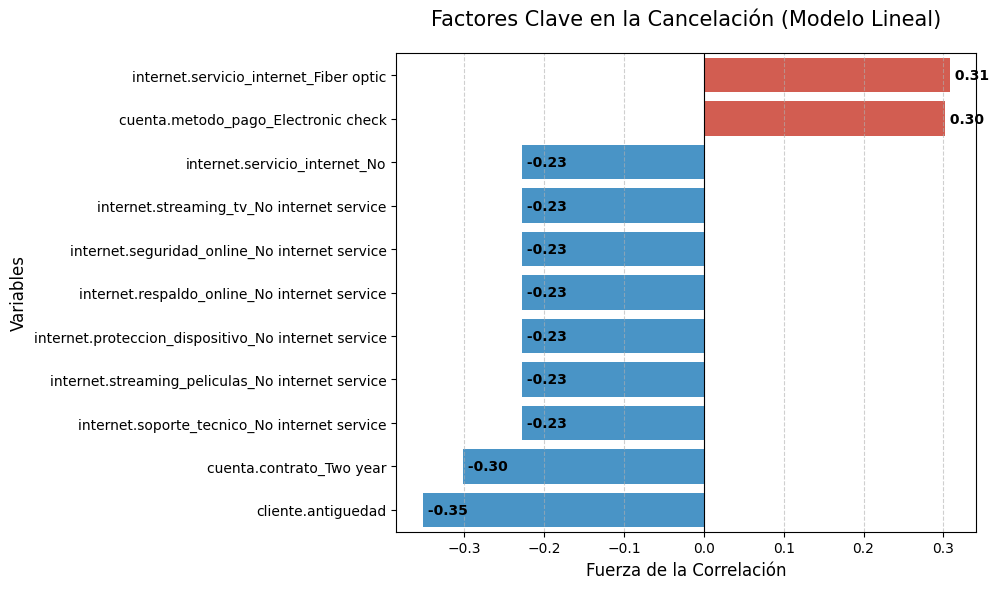

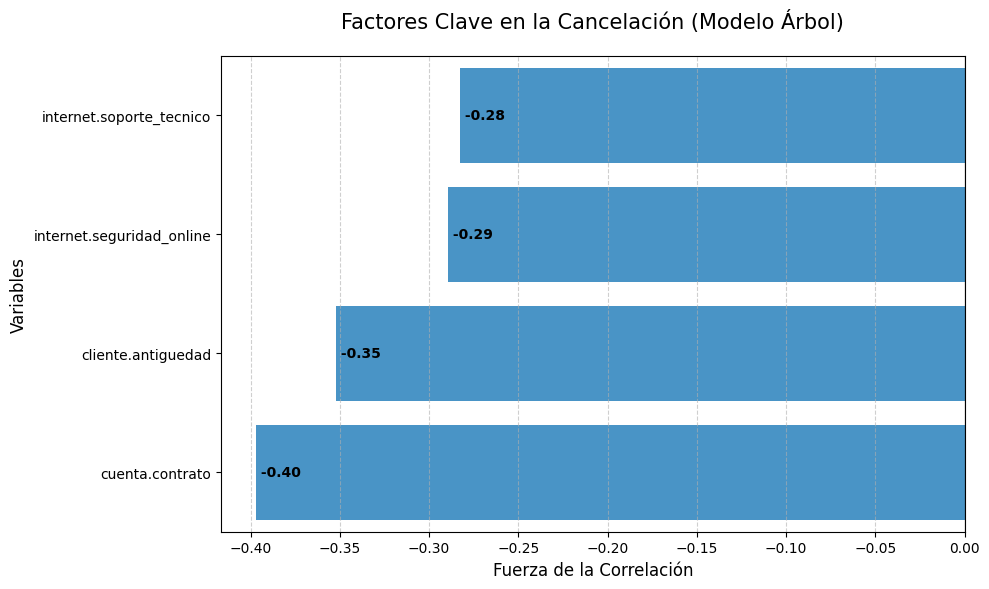

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_correlations(df, title, umbral=0.2):
    # 1. Calcular correlación
    corr_target = df.corr()['cancelacion'].sort_values(ascending=False)
    corr_filtrada = corr_target[(corr_target.abs() > umbral) & (corr_target.index != 'cancelacion')]

    # 2. Configurar el gráfico
    plt.figure(figsize=(10, 6))
    colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_filtrada]

    # --- CORRECCIÓN AQUÍ ---
    sns.barplot(
        x=corr_filtrada.values,
        y=corr_filtrada.index,
        palette=colors,
        hue=corr_filtrada.index,  # Asignamos el índice a hue
        legend=False              # Desactivamos la leyenda para que no estorbe
    )
    # -----------------------

    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f"Factores Clave en la {title}", fontsize=15, pad=20)
    plt.xlabel("Fuerza de la Correlación", fontsize=12)
    plt.ylabel("Variables", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    for i, v in enumerate(corr_filtrada.values):
        plt.text(v, i, f' {v:.2f}', va='center', fontsize=10,
                 fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

    # --- Ejecutar para ambos DataFrames ---
plot_top_correlations(df_lineal, "Cancelación (Modelo Lineal)", umbral=0.2)
plot_top_correlations(df_arbol, "Cancelación (Modelo Árbol)", umbral=0.2)

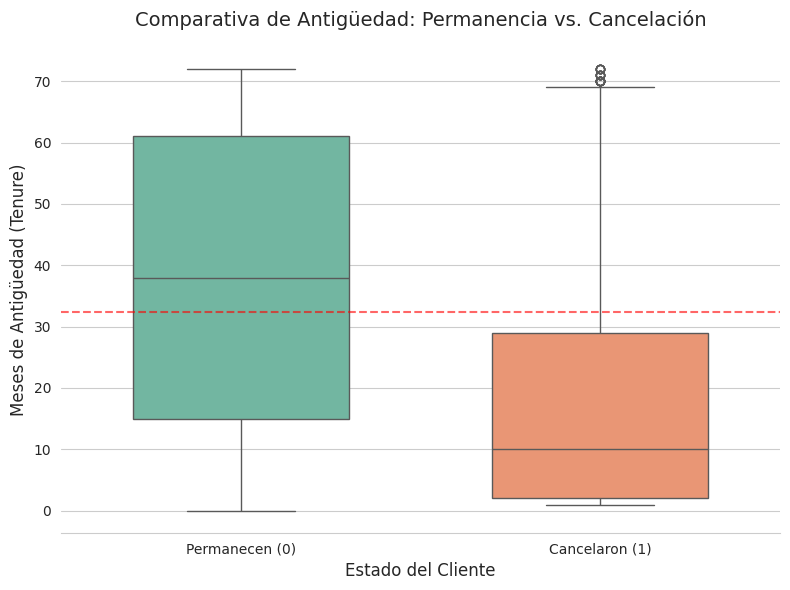

In [25]:
 plt.figure(figsize=(8, 6))
sns.set_style("whitegrid") # Whitegrid ayuda a seguir mejor los niveles de los meses

# Dibujar el boxplot tradicional
sns.boxplot(
    x="cancelacion",
    y="cliente.antiguedad",
    data=df_lineal,
    palette="Set2",
    hue="cancelacion", # Evita el aviso de depreciación
    legend=False,
    width=0.6          # Un poco más delgado para que se vea más elegante
)

# Añadir títulos y etiquetas claras
plt.title("Comparativa de Antigüedad: Permanencia vs. Cancelación", fontsize=14, pad=15)
plt.xlabel("Estado del Cliente", fontsize=12)
plt.ylabel("Meses de Antigüedad (Tenure)", fontsize=12)

# Cambiar los ticks del eje X por etiquetas legibles
plt.xticks([0, 1], ["Permanecen (0)", "Cancelaron (1)"])

# Opcional: añadir una línea con la media global de antigüedad
antiguedad_media = df_lineal["cliente.antiguedad"].mean()
plt.axhline(antiguedad_media, color='red', linestyle='--', alpha=0.6, label=f'Media: {antiguedad_media:.1f}')

sns.despine(left=True) # Limpieza visual
plt.tight_layout()
plt.show()



In [26]:
# 1. Antigüedad (ya definido arriba)

# 2. Contrato de 2 años (Comparativa)
plot_cancelacion_proporcion_mejorado(df_lineal, "cuenta.contrato_Two year", "Impacto del Contrato a Largo Plazo en la Retención")

# 3. Pago con Cheque Electrónico
plot_cancelacion_proporcion_mejorado(df_lineal, "cuenta.metodo_pago_Electronic check", "Riesgo de Cancelación: Pago con Cheque Electrónico")

# 4. Fibra Óptica
plot_cancelacion_proporcion_mejorado(df_lineal, "internet.servicio_internet_Fiber optic", "Análisis de Fuga en Usuarios de Fibra Óptica")

NameError: name 'plot_cancelacion_proporcion_mejorado' is not defined

In [ ]:
# Función auxiliar para graficar proporciones de cancelación
def plot_cancelacion_proporcion(df, columna, titulo):
    prop = df.groupby(columna)["cancelacion"].value_counts(normalize=True).rename("proporcion").reset_index()
    plt.figure(figsize=(6,4))
    sns.barplot(x=columna, y="proporcion", hue="cancelacion", data=prop)
    plt.title(titulo)
    plt.ylabel("Proporción")
    plt.show()

# Antigüedad del cliente
plt.figure(figsize=(6,4))
sns.boxplot(x="cancelacion", y="cliente.antiguedad", data=df_lineal)
plt.title("Antigüedad del cliente según cancelación")
plt.show()

# Contrato de 2 años
plot_cancelacion_proporcion(df_lineal, "cuenta.contrato_Two year", "Cancelación según Contrato de Dos Años")

# Método de pago Electronic Check
plot_cancelacion_proporcion(df_lineal, "cuenta.metodo_pago_Electronic check", "Cancelación según Pago Electronic Check")

# Internet Fiber optic
plot_cancelacion_proporcion(df_lineal, "internet.servicio_internet_Fiber optic", "Cancelación según Internet Fiber Optic")


In [ ]:
#modelo predictivo
from sklearn.model_selection import train_test_split

# División 70/30 en df_lineal
X_train_lineal, X_test_lineal, y_train_lineal, y_test_lineal = train_test_split(
    X_lineal_over, y_lineal_over, test_size=0.3, random_state=42, stratify=y_lineal_over
)

# División 70/30 en df_arbol
X_train_arbol, X_test_arbol, y_train_arbol, y_test_arbol = train_test_split(
    X_arbol_over, y_arbol_over, test_size=0.3, random_state=42, stratify=y_arbol_over
)

# Verificación de tamaños
print("Tamaños df_lineal:")
print("Entrenamiento:", X_train_lineal.shape, "Prueba:", X_test_lineal.shape)

print("\nTamaños df_arbol:")
print("Entrenamiento:", X_train_arbol.shape, "Prueba:", X_test_arbol.shape)

In [ ]:
import numpy as np
def plot_confusion_matrix_improved(y_true, y_pred, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    # Calcular porcentajes por fila (proporción de predicciones correctas por clase real)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Crear etiquetas combinadas: Número + Porcentaje
    labels = [f"{v}\n({p:.1%})" for v, p in zip(cm.flatten(), cm_perc.flatten())]
    labels = np.array(labels).reshape(2, 2)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=labels, fmt="", cmap=cmap, cbar=False,
                xticklabels=["Se Queda", "Cancela"],
                yticklabels=["Se Queda", "Cancela"],
                annot_kws={"size": 12, "weight": "bold"})

    plt.title(title, fontsize=15, pad=20)
    plt.xlabel("Predicción del Modelo", fontsize=12)
    plt.ylabel("Realidad del Cliente", fontsize=12)
    plt.tight_layout()
    plt.show()

# =======================
# Ejecución de los nuevos gráficos
# =======================

# Visualización para Regresión Logística
plot_confusion_matrix_improved(y_test_lineal, y_pred_lineal,
                             "Matriz de Confusión: Regresión Logística",
                             cmap="Blues")

# Visualización para Random Forest
plot_confusion_matrix_improved(y_test_arbol, y_pred_arbol,
                             "Matriz de Confusión: Random Forest",
                             cmap="Greens")

In [ ]:
# Datos de métricas
resultados = {
    "Métrica": ["Accuracy", "Precisión", "Recall", "F1-Score"],
    "Regresión Logística": [0.74, 0.51, 0.80, 0.62],
    "Random Forest": [0.78, 0.57, 0.65, 0.61]
}

df_metrics = pd.DataFrame(resultados).melt(id_vars="Métrica", var_name="Modelo", value_name="Valor")

# Gráfico de barras agrupadas profesional
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(data=df_metrics, x="Métrica", y="Valor", hue="Modelo", palette=["#3498db", "#2ecc71"])

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title("Comparativa de Modelos: Rendimiento en Predicción de Churn", fontsize=15, pad=20)
plt.ylim(0, 1.0)
plt.ylabel("Puntaje (0-1)")
plt.legend(title="Algoritmo", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.show()

In [ ]:
def plot_conf_matrix_pro(matrix, title, color="Blues"):
    plt.figure(figsize=(6, 5))

    # Calcular porcentajes
    group_counts = ["{0:0.0f}".format(value) for value in np.array(matrix).flatten()]
    group_percentages = ["{0:.1%}".format(value) for value in np.array(matrix).flatten()/np.sum(matrix)]

    # Etiquetas personalizadas para el negocio
    box_labels = [f"{v}\n{p}" for v, p in zip(group_counts, group_percentages)]
    box_labels = np.asarray(box_labels).reshape(2,2)

    sns.heatmap(matrix, annot=box_labels, fmt="", cmap=color, cbar=False,
                xticklabels=['Se Queda', 'Cancela'],
                yticklabels=['Se Queda', 'Cancela'],
                annot_kws={"size": 13, "weight": "bold"})

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Predicción (Sugerencia del IA)", fontsize=11)
    plt.ylabel("Realidad (Lo que hizo el cliente)", fontsize=11)
    plt.show()

# Ejecutar para tus dos matrices
plot_conf_matrix_pro(matriz_log, "Efectividad: Regresión Logística", color="Blues")
plot_conf_matrix_pro(matriz_rf, "Efectividad: Random Forest", color="Greens")

In [ ]:
# Combinar top 10 positivos y top 10 negativos
top_impacto = pd.concat([coeficientes.head(10), coeficientes.tail(10)])

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Crear colores basados en el valor del coeficiente
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_impacto['Coeficiente']]

ax = sns.barplot(data=top_impacto, x="Coeficiente", y="Variable", palette=colors, hue="Variable", legend=False)

# Línea central y etiquetas
plt.axvline(0, color='black', linewidth=1)
plt.title("Factores de Influencia en la Cancelación (Regresión Logística)\n¿Qué aumenta o disminuye el riesgo?", fontsize=14, pad=20)
plt.xlabel("Impacto del Coeficiente", fontsize=12)
plt.ylabel("Atributos del Cliente", fontsize=12)

# Anotaciones explicativas
plt.text(top_impacto['Coeficiente'].max()*0.5, len(top_impacto)-1, "Aumenta Riesgo ↗", color="#e74c3c", fontweight='bold', ha='center')
plt.text(top_impacto['Coeficiente'].min()*0.5, len(top_impacto)-1, "↘ Aumenta Retención", color="#3498db", fontweight='bold', ha='center')

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))
sns.set_style("white")

# Seleccionar top 12 para dar más contexto
top_rf = importancias.head(12)

# Paleta de colores degradada (resaltando los primeros)
pal = sns.color_palette("Greens_r", len(top_rf))

ax = sns.barplot(data=top_rf, x="Importancia", y="Variable", palette=pal, hue="Variable", legend=False)

# Añadir valores de importancia al final de cada barra
for i, v in enumerate(top_rf['Importancia']):
    ax.text(v + 0.002, i, f'{v:.1%}', color='black', va='center', fontweight='bold')

plt.title("Variables con Mayor Poder Predictivo (Random Forest)\nFactores clave para el modelo", fontsize=14, pad=20)
plt.xlabel("Peso en la decisión del modelo", fontsize=12)
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.4)

sns.despine(left=True)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# Importancia de variables - Regresión Logística
# =========================================================

# Extraer coeficientes del modelo logístico
# Access the LogisticRegression model within the pipeline
coeficientes = pd.DataFrame({
    "Variable": X_train_lineal.columns,
    "Coeficiente": modelo_lineal.named_steps['clf'].coef_[0] # Access coef_ from the 'clf' step
})

# Ordenar de mayor a menor
coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

print("Top 10 variables que AUMENTAN la probabilidad de cancelación:")
display(coeficientes.head(10))

print("\nTop 10 variables que REDUCEN la probabilidad de cancelación:")
display(coeficientes.tail(10))

# Visualización rápida de los coeficientes
plt.figure(figsize=(8,6))
sns.barplot(data=coeficientes.head(10), x="Coeficiente", y="Variable", color="red")
plt.title("Top 10 variables más influyentes (+) - Regresión Logística")
plt.show()

plt.figure(figsize=(8,6))
sns.barplot(data=coeficientes.tail(10), x="Coeficiente", y="Variable", color="blue")
plt.title("Top 10 variables más influyentes (-) - Regresión Logística")
plt.show()


# =========================================================
# 🌲 Importancia de variables - Random Forest
# =========================================================

# Access feature_importances_ from the 'clf' step in the Random Forest pipeline
importancias = pd.DataFrame({
    "Variable": X_train_arbol.columns,
    "Importancia": modelo_arbol.named_steps['clf'].feature_importances_
})

# Ordenar de mayor a menor
importancias = importancias.sort_values(by="Importancia", ascending=False)

print("\nTop 10 variables más importantes en Random Forest:")
display(importancias.head(10))

# Visualización
plt.figure(figsize=(8,6))
sns.barplot(
    data=importancias.head(10),
    x="Importancia",
    y="Variable",
    hue="Variable",
    dodge=False,
    palette="viridis",
    legend=False
)
plt.title("Top 10 variables más importantes - Random Forest")
plt.show()

#📄Informe final

Se analizaron los datos de comportamiento de clientes, servicios y facturación mediante técnicas de Machine Learning. Se desarrollaron dos enfoques principales: Regresión Logística (priorizando la detección masiva de riesgos) y Random Forest (priorizando la precisión y estabilidad). Los resultados indican que el tipo de contrato y la tecnología de internet son los principales detonantes de abandono.

Se estructuró en cuatro fases críticas:

Normalización: Se aplanaron estructuras JSON anidadas para convertir atributos de servicio (internet, phone, account) en variables tabulares.

Ingeniería de Atributos: Se creó la métrica cuenta.cuentas_diarias y se eliminaron identificadores no predictivos.

Tratamiento de Desbalanceo: Dado que los clientes que cancelan son minoría, se aplicó SMOTE (Oversampling) para que el modelo aprenda adecuadamente los patrones de la clase minoritaria.

Codificación: Se utilizó Label Encoding para modelos de árboles y One-Hot Encoding para modelos lineales, asegurando la compatibilidad matemática.


El análisis de importancia de variables reveló los "puntos de dolor" del cliente:

Tipo de Contrato: Los contratos mes a mes presentan la probabilidad más alta de fuga. La falta de compromiso a largo plazo facilita la salida ante cualquier oferta de la competencia.

Tecnología de Internet: Sorprendentemente, los clientes con Fibra Óptica tienen mayor tendencia al churn que los de ADSL. Esto sugiere problemas potenciales en el precio del servicio o en la estabilidad técnica percibida.

Método de Pago: El uso de Cheque Electrónico está fuertemente vinculado a la cancelación, a diferencia de los pagos automáticos con tarjeta de crédito.

Cargos Mensuales: Existe una correlación positiva entre facturas elevadas y la probabilidad de abandono, especialmente si el cliente tiene baja antigüedad.

##Recomendaciones:

Basado en el modelo, se sugieren las siguientes acciones inmediatas:

Plan de Migración de Contratos: Diseñar campañas para mover a los clientes de "Mes a Mes" hacia planes anuales mediante bonificaciones de velocidad o descuentos por lealtad.

Auditoría de Servicio en Fibra Óptica: Realizar un análisis técnico y de satisfacción específico para el segmento de fibra para identificar por qué la tasa de abandono es superior en este grupo.

Incentivo a la Automatización de Pagos: Ofrecer un pequeño descuento (ej. 2-5%) a quienes cambien su método de pago de cheque electrónico a cargo automático en tarjeta de crédito.

Protocolo "First 6 Months": Implementar un sistema de contacto proactivo durante los primeros 6 meses de vida del cliente (tenure bajo), ya que es el periodo de mayor riesgo detectado.


##Conclusión final

Para una estrategia agresiva de retención, se recomienda implementar la Regresión Logística debido a su capacidad para no dejar escapar clientes en riesgo (Alto Recall). Si el presupuesto para campañas de retención es limitado, el Random Forest es la opción óptima para dirigir los recursos solo a quienes tienen una probabilidad de fuga muy certera.